# Physics-Informed ML Model: $q, \beta \to V_{\mathrm{LH}}$

The NN learns a local frequency $\omega_a(q;\,\theta)$ inside the analytical local-harmonic effective potential. With network weights $\theta$, the full model is:

$$V_{\mathrm{LH}}(q, \beta;\,\theta) \;=\; V(q)\,\Xi\!\bigl(\beta,\,\omega_a(q;\theta)\bigr) \;-\; \frac{1}{2\beta}\ln\Xi\!\bigl(\beta,\,\omega_a(q;\theta)\bigr)$$

where the smearing factor is

$$\Xi = \frac{\tanh\xi_a}{\xi_a}, \qquad \xi_a = \frac{\beta\hbar\,\omega_a(q;\,\theta)}{2}$$

The MSE loss $\mathcal{L} = \|V_{\mathrm{LH}} - U_{\mathrm{eff}}\|^2$ propagates gradients back through the entire expression to update $\theta$, so the NN is trained on how well the complete physics formula matches the exact quantum result:

$$\theta \;\longrightarrow\; \mathrm{net}_\theta(q) \;\longrightarrow\; \mathrm{softplus} \;\longrightarrow\; \omega_a \;\longrightarrow\; \xi_a \;\longrightarrow\; \Xi \;\longrightarrow\; V_{\mathrm{LH}} \;\longrightarrow\; \mathcal{L}$$

$\omega_a(q)$ is the local harmonic frequency — for the QHO with $V = \frac{1}{2}q^2$, the exact value is $\omega_a = 1$ everywhere. The network outputs $\omega_a(q;\theta) > 0$ (enforced by softplus). All temperature dependence enters analytically through $\Xi(\beta,\,\omega_a)$.

## Data

Reference data $U_{\mathrm{eff}}^{\mathrm{num}}$ is generated by the same numerical solver as in Notebooks 2 and 3 ($U_{\mathrm{eff}}(0,\beta)=0$, atomic units), using 10 log-spaced temperatures $T \in [0.1, 10]$. The solver grid is trimmed by one unit at each edge to remove finite-difference boundary errors:

| Solver grid | ML region | Positions (post-trim) | Temperatures | Total points |
|-------------|-----------|-----------------------|--------------|--------------|
| $[-10, 10]$ | $(-9, 9)$ | 180 | 10 | 1800 |

**Train/Validation/Test split:** 10 position indices are held out for validation and 10 for testing, with the same indices withheld at every temperature.

| Train | Validation | Test |
|-------|------------|------|
| 1600 | 100 | 100 |

## Model

The physics-informed model $\mathrm{NN}_\theta : q \mapsto \omega_a(q)$ is a feedforward network with one hidden layer of 16 neurons and $\tanh$ activations, followed by softplus to enforce positivity. Weights are Xavier-uniform initialised and optimised with AdamW ($\eta = 10^{-3}$, weight decay $1.0$) using unweighted MSE loss with validation-based early stopping. The stronger weight decay regularises $\omega_a$ toward smaller-magnitude weights and reduces variation around the true value $\omega_a = 1$.

$$\mathcal{L}(\theta) = \frac{1}{N_{\mathrm{train}}} \sum_{i=1}^{N_{\mathrm{train}}} \left[ V_{\mathrm{LH}}(q_i, \beta_i;\,\theta) - U_{\mathrm{eff}}^{\mathrm{num}}(q_i, \beta_i) \right]^2$$

Full analysis (learning curves, $\omega_a(q)$ diagnostic, and temperature extrapolation) is performed on the QHO.

In [ ]:
import numpy as np
import torch
from torch import nn
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
from matplotlib.patches import Patch
import copy
from google.colab import files


## Numerical Solver

In [ ]:
class QuantumSystem1D:
    """
    Lean quantum solver: diagonalises the 1D Hamiltonian and computes
    the effective potential U_eff(q, β) from the thermal density matrix.

    Uses atomic units: ℏ = m = ω = k_B = 1.
    """

    def __init__(self, V, qmin, qmax, n_points, m=1.0, ℏ=1.0):
        self.V = V
        self.qmin = qmin
        self.qmax = qmax
        self.n_points = n_points
        self.m = m
        self.ℏ = ℏ
        self.q_grid = np.linspace(qmin, qmax, n_points)
        self.q_delta = self.q_grid[1] - self.q_grid[0]
        self._solve_eigenproblem()

    def _solve_eigenproblem(self):
        """Construct and diagonalise the Hamiltonian (finite-difference discretisation)."""
        H = np.zeros((self.n_points, self.n_points))
        kinetic_diag = self.ℏ**2 / (self.m * self.q_delta**2)
        kinetic_off  = -self.ℏ**2 / (2.0 * self.m * self.q_delta**2)

        for i in range(self.n_points):
            for j in range(self.n_points):
                if i == j:
                    H[i, j] = kinetic_diag + self.V(self.q_grid[i])[0]
                elif abs(i - j) == 1:
                    H[i, j] = kinetic_off

        eigenvalues, eigenvectors = np.linalg.eigh(H)
        eigenvectors = eigenvectors.T
        for i in range(len(eigenvectors)):
            norm = np.sqrt(np.trapz(eigenvectors[i]**2, self.q_grid))
            eigenvectors[i] /= norm

        self.eigenvalues = eigenvalues
        self.eigenvectors = eigenvectors
        print(f"Solved: {self.n_points} states, E₀ = {eigenvalues[0]:.6f}, E₁ = {eigenvalues[1]:.6f}")

    def thermal_density_diagonal(self, β):
        """⟨q|e^{-βH}|q⟩ = Σₙ |ψₙ(q)|² e^{-β Eₙ}"""
        ρ = np.zeros_like(self.q_grid)
        for E, ψ in zip(self.eigenvalues, self.eigenvectors):
            ρ += ψ**2 * np.exp(-β * E)
        return ρ

    def effective_potential_quantum(self, β):
        """U_eff(q, β) = -(1/β) ln ρ(q,q;β), pinned so U_eff(0) = 0."""
        ρ = self.thermal_density_diagonal(β)
        U = -(1.0 / β) * np.log(np.maximum(ρ, 1e-300))
        q0_idx = np.argmin(np.abs(self.q_grid))
        return U - U[q0_idx]

## Potential and Data Generation

In [ ]:
def V_harmonic(q):
    k = 1.0
    return 0.5 * k * q**2, k * q, k * q**0

# solver generates data on the full grid [-10, 10]
system = QuantumSystem1D(V_harmonic, qmin=-10, qmax=10, n_points=200, m=1.0, ℏ=1.0)
q_grid_full = system.q_grid.copy()
n_pos_full  = len(q_grid_full)

n_temperatures = 10
temperatures = np.logspace(np.log10(0.1), np.log10(10.0), n_temperatures)

U_eff_full = np.zeros((n_temperatures, n_pos_full))
for i, T in enumerate(temperatures):
    U_eff_full[i] = system.effective_potential_quantum(1.0 / T)

# restrict to |q| < 9 for all ML work — avoids boundary artefacts at ±10
mask_q    = (q_grid_full > -9) & (q_grid_full < 9)
q_grid    = q_grid_full[mask_q]
n_pos     = len(q_grid)
U_eff_data = U_eff_full[:, mask_q]
sigma_U   = np.array([np.std(U_eff_data[i]) for i in range(n_temperatures)])

print(f"Solver:    {n_temperatures} temperatures × {n_pos_full} positions")
print(f"ML region: {n_pos} positions in |q| < 9")
print(f"T range:   [{temperatures[0]:.4f}, {temperatures[-1]:.4f}]")

Solved: 200 states, E₀ = 0.499684, E₁ = 1.498420
Solver:    10 temperatures × 200 positions
ML region: 180 positions in |q| < 9
T range:   [0.1000, 10.0000]


/tmp/ipykernel_12318/4061324253.py:36: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  norm = np.sqrt(np.trapz(eigenvectors[i]**2, self.q_grid))


## Physics-Informed Model and Training

In [ ]:
class PhysicsInformedModel(nn.Module):
    """
    NN learns local frequency ω_a(q; θ) inside the analytical V_LH formula.
    Temperature dependence is handled analytically — the NN sees only position.

    Forward pass: q, β → V_LH(q, β)
    """

    def __init__(self, V_torch, hidden_dims=[16], ℏ=1.0, m=1.0):
        super().__init__()
        self.V_torch = V_torch
        self.ℏ = ℏ
        self.m = m

        layers = []
        d_in = 1
        for d_h in hidden_dims:
            layers.append(nn.Linear(d_in, d_h))
            layers.append(nn.Tanh())
            d_in = d_h
        layers.append(nn.Linear(d_in, 1))
        self.net = nn.Sequential(*layers)

        for layer in self.net:
            if isinstance(layer, nn.Linear):
                nn.init.xavier_uniform_(layer.weight)
                nn.init.zeros_(layer.bias)

    def get_omega(self, q):
        """Return ω_a(q) > 0 (softplus enforced)."""
        return nn.functional.softplus(self.net(q))

    def forward(self, q, β):
        """q: (N,1), β: scalar or (N,1). Returns V_LH(q,β) as (N,1)."""
        ω      = self.get_omega(q)
        ξ      = β * self.ℏ * ω / 2.0
        ξ_safe = torch.clamp(ξ, min=1e-8)
        Ξ      = torch.tanh(ξ_safe) / ξ_safe

        V    = self.V_torch(q)
        V_LH = V * Ξ - (1.0 / (2.0 * β)) * torch.log(torch.clamp(Ξ, min=1e-30))

        # subtract V_LH at origin to match numerical offset convention U_eff(0) = 0
        ω_0    = self.get_omega(torch.zeros(1, 1))
        ξ_0    = β * self.ℏ * ω_0 / 2.0
        ξ_0s   = torch.clamp(ξ_0, min=1e-8)
        Ξ_0    = torch.tanh(ξ_0s) / ξ_0s
        V_0    = self.V_torch(torch.zeros(1, 1))
        V_LH_0 = V_0 * Ξ_0 - (1.0 / (2.0 * β)) * torch.log(torch.clamp(Ξ_0, min=1e-30))

        return V_LH - V_LH_0


def train_physics_informed(model, q_train, β_train, y_train,
                           q_val, β_val, y_val, epochs, lr):
    """Train with validation-based model selection."""
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1)
    best_val_loss = float('inf')
    best_state = None
    train_hist, val_hist = [], []

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        pred = model(q_train, β_train)
        loss = nn.functional.mse_loss(pred, y_train)
        loss.backward()
        optimizer.step()
        train_hist.append(loss.item())

        model.eval()
        with torch.no_grad():
            val_loss = nn.functional.mse_loss(model(q_val, β_val), y_val).item()
            val_hist.append(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())

    model.load_state_dict(best_state)
    return model, train_hist, val_hist


def compute_rmse(model, q, β, y_np):
    """Unweighted RMSE on a dataset."""
    model.eval()
    with torch.no_grad():
        pred = model(q, β).numpy()
    return np.sqrt(np.mean((pred - y_np)**2))

## Data Splits and Training Setup

Position indices are randomly partitioned into train, validation and test sets — the same positions are held out at every temperature. The remaining training positions form nested subsets (controlled by `training_fractions`) to characterise data efficiency.

In [ ]:
hidden_dims = [16]
epochs      = 3000
lr          = 0.001
seed        = 0

training_fractions = [0.05, 0.10, 0.20, 0.25, 0.40, 0.50, 0.75, 0.80, 1.00]
n_fracs = len(training_fractions)

n_test_per_T = 10
n_val_per_T  = 10

rng = np.random.default_rng(seed=seed)
idx_shuf = rng.permutation(n_pos)
test_positions = set(idx_shuf[:n_test_per_T])
val_positions  = set(idx_shuf[n_test_per_T:n_test_per_T + n_val_per_T])

# build flat arrays: one entry per (q, T) pair
all_q = np.tile(q_grid, n_temperatures)
all_β = np.repeat(1.0 / temperatures, n_pos)
all_U = U_eff_data.flatten()

j_indices = np.tile(np.arange(n_pos), n_temperatures)
is_test  = np.isin(j_indices, list(test_positions))
is_val   = np.isin(j_indices, list(val_positions))
is_train = ~is_test & ~is_val

# reshape for model: (N, 1)
q_train_np = all_q[is_train].reshape(-1, 1)
β_train_np = all_β[is_train].reshape(-1, 1)
y_train_np = all_U[is_train].reshape(-1, 1)

q_val_np = all_q[is_val].reshape(-1, 1)
β_val_np = all_β[is_val].reshape(-1, 1)
y_val_np = all_U[is_val].reshape(-1, 1)

q_test_np = all_q[is_test].reshape(-1, 1)
β_test_np = all_β[is_test].reshape(-1, 1)
y_test_np = all_U[is_test].reshape(-1, 1)

sigma_U_all = np.std(all_U)

print(f"Train: {is_train.sum()}  Val: {is_val.sum()}  Test: {is_test.sum()}")

Train: 1600  Val: 100  Test: 100


## Training

A model is trained for each training fraction. The full-data model ($f = 1.0$) is retained for the prediction and diagnostic plots.

In [ ]:
n_train_total = len(q_train_np)
rng_t = np.random.default_rng(seed=seed)
shuf = rng_t.permutation(n_train_total)
q_train_shuf = q_train_np[shuf]
β_train_shuf = β_train_np[shuf]
y_train_shuf = y_train_np[shuf]

qv  = torch.tensor(q_val_np,  dtype=torch.float32)
βv  = torch.tensor(β_val_np,  dtype=torch.float32)
yv  = torch.tensor(y_val_np,  dtype=torch.float32)
qte = torch.tensor(q_test_np, dtype=torch.float32)
βte = torch.tensor(β_test_np, dtype=torch.float32)

p_rmse   = np.zeros(n_fracs)
p_rel    = np.zeros(n_fracs)
p_ntrain = np.zeros(n_fracs, dtype=int)
best_model = None

V_torch = lambda q: 0.5 * q**2

for f_idx, frac in enumerate(training_fractions):
    n_train = max(1, int(n_train_total * frac))

    qt = torch.tensor(q_train_shuf[:n_train], dtype=torch.float32)
    βt = torch.tensor(β_train_shuf[:n_train], dtype=torch.float32)
    yt = torch.tensor(y_train_shuf[:n_train], dtype=torch.float32)

    model = PhysicsInformedModel(V_torch=V_torch, hidden_dims=hidden_dims)
    model, _, _ = train_physics_informed(model, qt, βt, yt, qv, βv, yv, epochs, lr)

    p_rmse[f_idx]   = compute_rmse(model, qte, βte, y_test_np)
    p_rel[f_idx]    = p_rmse[f_idx] / sigma_U_all
    p_ntrain[f_idx] = n_train

    if frac == 1.0:
        best_model = model

    print(f"{frac*100:5.0f}%: n={n_train:4d}  ε_rel^test={p_rel[f_idx]:.4f}")

print("\nTraining complete.")

    5%: n=  80  ε_rel^test=0.0039
   10%: n= 160  ε_rel^test=0.0030
   20%: n= 320  ε_rel^test=0.0025
   25%: n= 400  ε_rel^test=0.0042
   40%: n= 640  ε_rel^test=0.0023
   50%: n= 800  ε_rel^test=0.0031
   75%: n=1200  ε_rel^test=0.0026
   80%: n=1280  ε_rel^test=0.0030
  100%: n=1600  ε_rel^test=0.0020

Training complete.


## Results

### Predictions at Each Temperature

The full-data model is evaluated across $q \in (-9, 9)$. Solid black: numerical $U_{\mathrm{eff}}^{\mathrm{num}}$; dashed purple: physics-informed $V_{\mathrm{LH}}^{\mathrm{NN}}$.

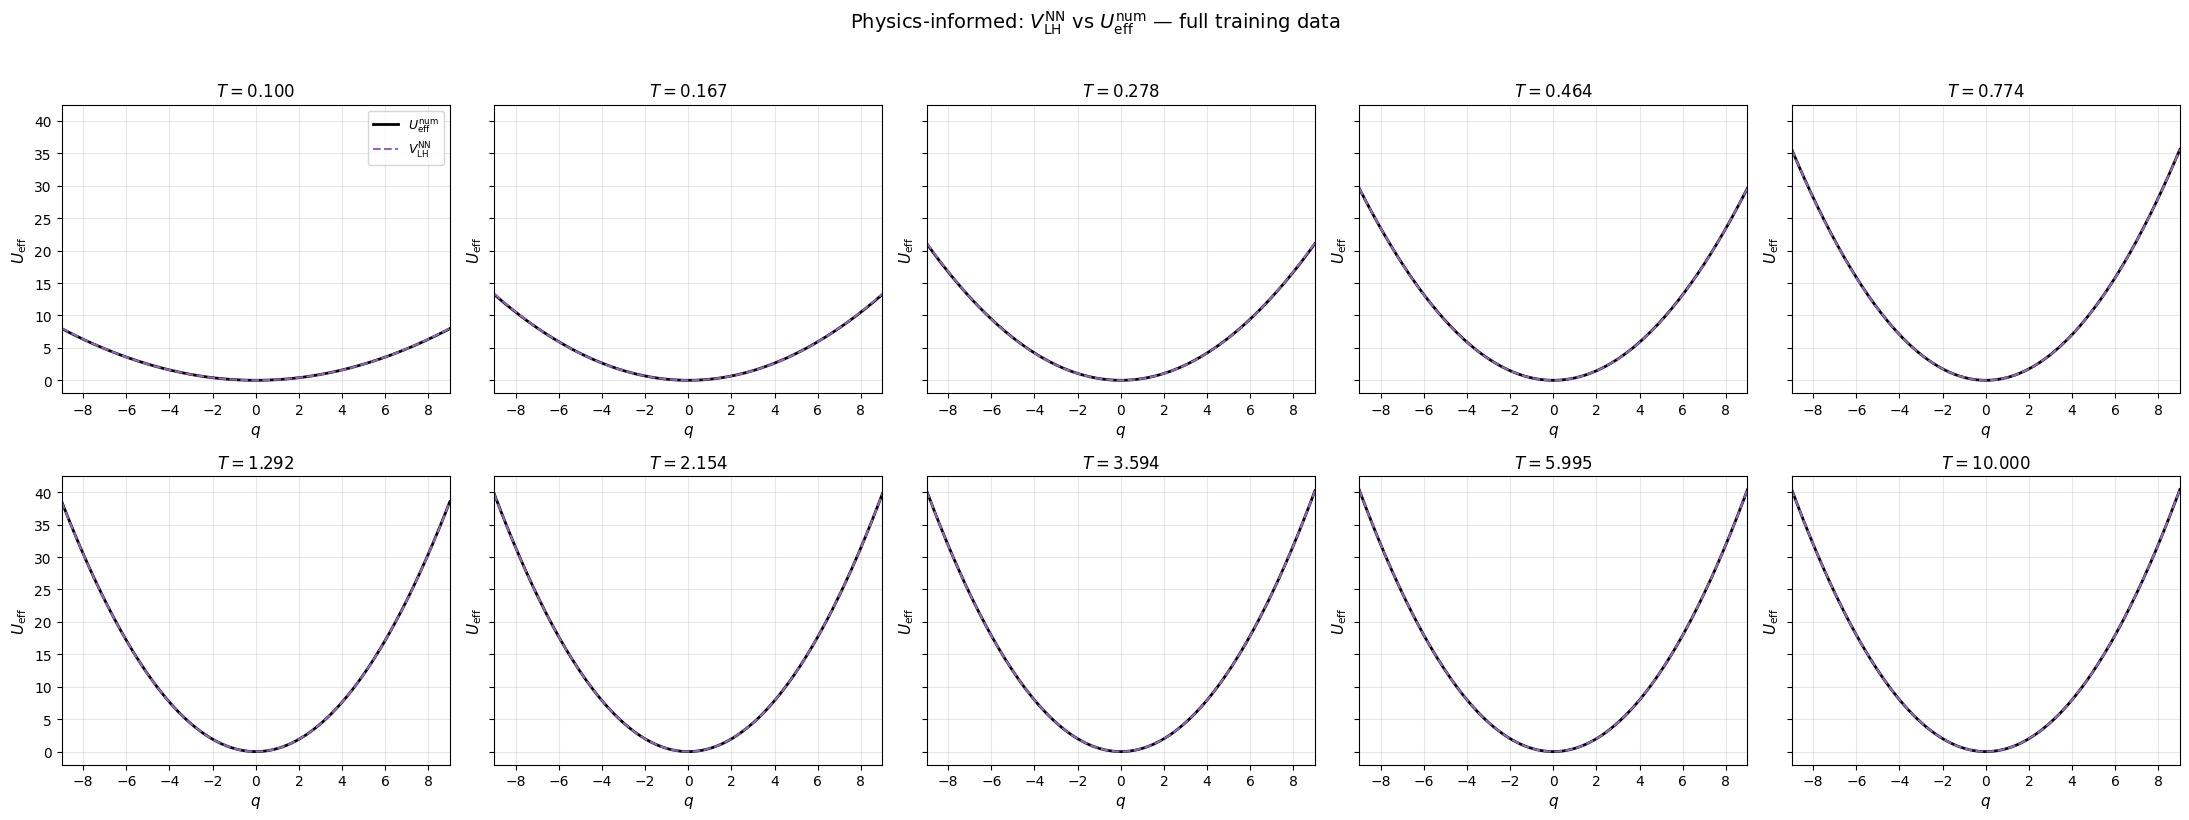

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(22, 8), sharey=True)
best_model.eval()
q_dense = np.linspace(-9, 9, 500).reshape(-1, 1)
q_dense_t = torch.tensor(q_dense, dtype=torch.float32)

for idx, ax in enumerate(axes.flatten()):
    T = temperatures[idx]
    β = 1.0 / T
    β_t = torch.full_like(q_dense_t, β)

    with torch.no_grad():
        y_pred = best_model(q_dense_t, β_t).numpy().flatten()

    ax.plot(q_grid, U_eff_data[idx], 'k-', lw=2, label=r'$U_{\mathrm{eff}}^{\mathrm{num}}$')
    ax.plot(q_dense.flatten(), y_pred, '--', color='tab:purple', lw=1.5, label=r'$V_{\mathrm{LH}}^{\mathrm{NN}}$')
    ax.set_xlabel(r'$q$', fontsize=11)
    ax.set_ylabel(r'$U_{\mathrm{eff}}$', fontsize=11)
    ax.set_title(f'$T = {T:.3f}$', fontsize=12)
    ax.set_xlim(-9, 9)
    ax.grid(True, alpha=0.3)
    if idx == 0: ax.legend(fontsize=9)

fig.suptitle(r'Physics-informed: $V_{\mathrm{LH}}^{\mathrm{NN}}$ vs $U_{\mathrm{eff}}^{\mathrm{num}}$ — full training data',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('pi_predictions.pdf', bbox_inches='tight', dpi=300)
plt.show()
files.download('pi_predictions.pdf')

### Learned Local Frequency $\omega_a(q)$

Key diagnostic: should be flat at $\omega_a = 1$ for the QHO.

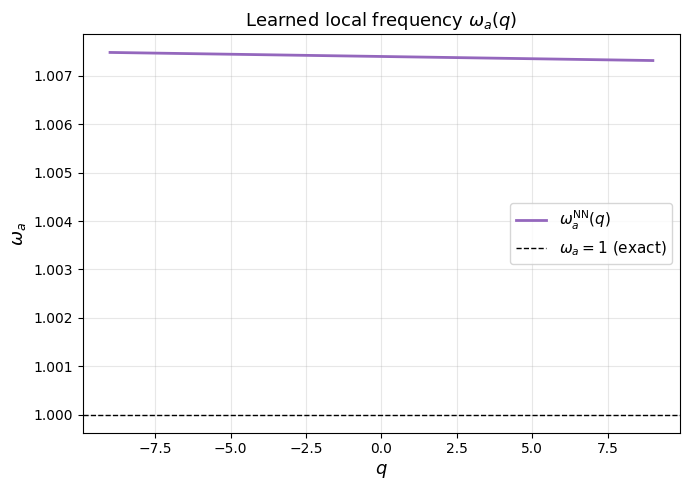

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
best_model.eval()
with torch.no_grad():
    omega_learned = best_model.get_omega(q_dense_t).numpy().flatten()

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(q_dense.flatten(), omega_learned, '-', color='tab:purple', lw=2, label=r'$\omega_a^{\mathrm{NN}}(q)$')
ax.axhline(1.0, color='k', ls='--', lw=1, label=r'$\omega_a = 1$ (exact)')
ax.set_xlabel(r'$q$', fontsize=13)
ax.set_ylabel(r'$\omega_a$', fontsize=13)
ax.set_title(r'Learned local frequency $\omega_a(q)$', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('pi_omega.pdf', bbox_inches='tight', dpi=300)
plt.show()
files.download('pi_omega.pdf')

### Per-Temperature Relative Error

The relative RMSE $\varepsilon_{\mathrm{rel}}^{\mathrm{test}}(T) = \mathrm{RMSE}_{\mathrm{test}}(T) / \sigma(U_{\mathrm{eff}}^T)$ on the test set, evaluated using the full-data model at each temperature.

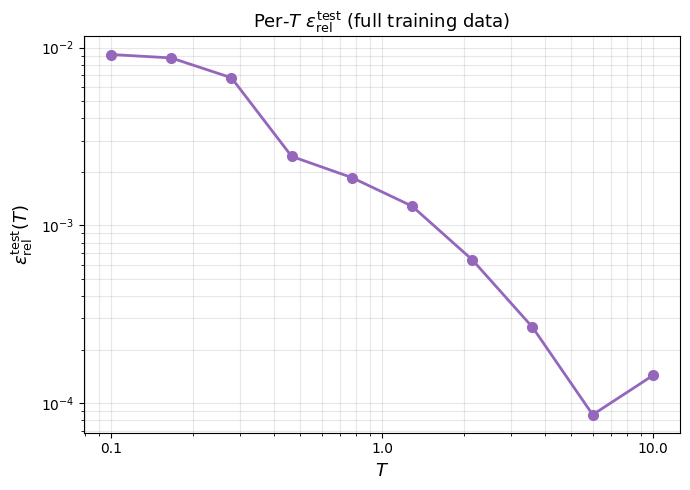

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

         T       ε_rel
    0.1000    0.009140
    0.1668    0.008743
    0.2783    0.006763
    0.4642    0.002443
    0.7743    0.001856
    1.2915    0.001282
    2.1544    0.000640
    3.5938    0.000267
    5.9948    0.000086
   10.0000    0.000143


In [ ]:
best_model.eval()
per_T_rmse = np.zeros(n_temperatures)
for t_idx, T in enumerate(temperatures):
    mask = is_test & (all_β == 1.0 / T)
    q_t = torch.tensor(all_q[mask].reshape(-1, 1), dtype=torch.float32)
    β_t = torch.tensor(all_β[mask].reshape(-1, 1), dtype=torch.float32)
    y_t = all_U[mask].reshape(-1, 1)
    per_T_rmse[t_idx] = compute_rmse(best_model, q_t, β_t, y_t)

per_T_rel = per_T_rmse / sigma_U

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(temperatures, per_T_rel, 'o-', color='tab:purple', lw=2, ms=7)
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel(r'$T$', fontsize=13)
ax.set_ylabel(r'$\varepsilon_{\mathrm{rel}}^{\mathrm{test}}(T)$', fontsize=13)
ax.set_title(r'Per-$T$ $\varepsilon_{\mathrm{rel}}^{\mathrm{test}}$ (full training data)', fontsize=13)
ax.grid(True, alpha=0.3, which='both')
ax.xaxis.set_major_formatter(ScalarFormatter())
plt.tight_layout()
plt.savefig('pi_error_vs_T.pdf', bbox_inches='tight', dpi=300)
plt.show()
files.download('pi_error_vs_T.pdf')
files.download('pi_error_vs_T.pdf')

print(f"{'T':>10}  {'ε_rel':>10}")
for T, e in zip(temperatures, per_T_rel):
    print(f"{T:10.4f}  {e:10.6f}")

### Learning Curve

$\varepsilon_{\mathrm{rel}}^{\mathrm{test}}$ as a function of training set size $N_{\mathrm{train}}$.

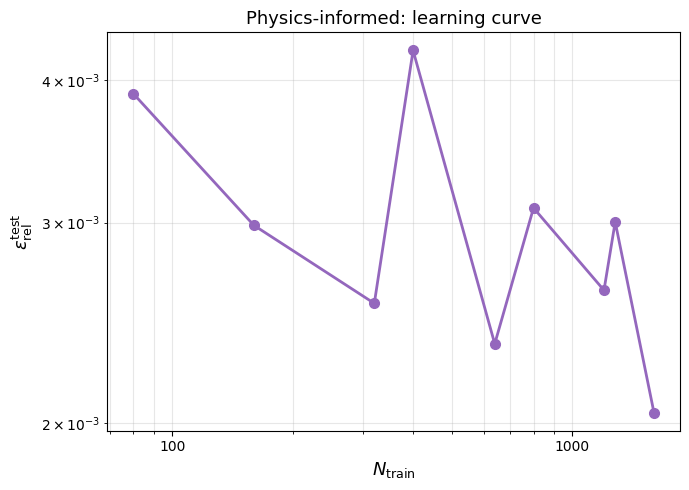

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(p_ntrain, p_rel, 'o-', color='tab:purple', lw=2, ms=7)
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel(r'$N_{\mathrm{train}}$', fontsize=13)
ax.set_ylabel(r'$\varepsilon_{\mathrm{rel}}^{\mathrm{test}}$', fontsize=13)
ax.set_title(r'Physics-informed: learning curve', fontsize=13)
ax.grid(True, alpha=0.3, which='both')
ax.xaxis.set_major_formatter(ScalarFormatter())
plt.tight_layout()
plt.savefig('pi_learning_curve.pdf', bbox_inches='tight', dpi=300)
plt.show()
files.download('pi_learning_curve.pdf')

## Temperature Extrapolation

Train the physics-informed model on **high-temperature data only** ($T \geq 1$), then evaluate on **unseen low-temperature data** ($T < 1$). Since $\omega_a(q)$ is temperature-independent, the analytical factor $\Xi(\beta, \omega_a)$ handles all temperature dependence. If the model learns a good $\omega_a$ from high-$T$ data, it should extrapolate to any $T$.

**Protocol:**
- **Train:** $T \geq 1$ (high-$T$, classical-like)
- **Test:** $T < 1$ (low-$T$, strong NQEs)

In [ ]:
high_T_idx = np.where(temperatures >= 1.0)[0]
low_T_idx  = np.where(temperatures <  1.0)[0]
high_T = temperatures[high_T_idx]
low_T  = temperatures[low_T_idx]

print(f"Train (T >= 1.0): {[f'{T:.4f}' for T in high_T]}")
print(f"Test  (T <  1.0): {[f'{T:.4f}' for T in low_T]}")

# build flat arrays — high-T only
U_eff_highT = np.zeros((len(high_T), n_pos))
for j, T in enumerate(high_T):
    U_eff_highT[j] = U_eff_data[high_T_idx[j]]

q_ex_np = np.tile(q_grid.reshape(-1, 1), (len(high_T), 1))
β_ex_np = np.repeat(1.0 / high_T, n_pos).reshape(-1, 1)
y_ex_np = U_eff_highT.reshape(-1, 1)

# 90/10 train/val split
rng_ex  = np.random.default_rng(seed=seed)
shuf_ex = rng_ex.permutation(len(q_ex_np))
n_val_ex = len(q_ex_np) // 10

qv_ex = torch.tensor(q_ex_np[shuf_ex[:n_val_ex]], dtype=torch.float32)
bv_ex = torch.tensor(β_ex_np[shuf_ex[:n_val_ex]], dtype=torch.float32)
yv_ex = torch.tensor(y_ex_np[shuf_ex[:n_val_ex]], dtype=torch.float32)
qt_ex = torch.tensor(q_ex_np[shuf_ex[n_val_ex:]], dtype=torch.float32)
bt_ex = torch.tensor(β_ex_np[shuf_ex[n_val_ex:]], dtype=torch.float32)
yt_ex = torch.tensor(y_ex_np[shuf_ex[n_val_ex:]], dtype=torch.float32)

print(f"\nTotal: {len(q_ex_np)}  |  Train: {len(qt_ex)}  Val: {len(qv_ex)}")

Train (T >= 1.0): ['1.2915', '2.1544', '3.5938', '5.9948', '10.0000']
Test  (T <  1.0): ['0.1000', '0.1668', '0.2783', '0.4642', '0.7743']

Total: 900  |  Train: 810  Val: 90


In [ ]:
extrap_model = PhysicsInformedModel(V_torch=V_torch, hidden_dims=hidden_dims)
extrap_model, _, _ = train_physics_informed(
    extrap_model, qt_ex, bt_ex, yt_ex,
    qv_ex, bv_ex, yv_ex,
    epochs=epochs, lr=lr)
print("Physics-informed extrapolation model trained.")

Physics-informed extrapolation model trained.


In [ ]:
extrap_model.eval()
q_col_t = torch.tensor(q_grid.reshape(-1, 1), dtype=torch.float32)

pi_pred_ex = np.zeros((n_temperatures, n_pos))
pi_rmse_ex = np.zeros(n_temperatures)

with torch.no_grad():
    for i, T in enumerate(temperatures):
        β = 1.0 / T
        β_t = torch.full_like(q_col_t, β)
        pi_p = extrap_model(q_col_t, β_t).numpy().flatten()
        pi_pred_ex[i] = pi_p
        pi_rmse_ex[i] = np.sqrt(np.mean((pi_p - U_eff_data[i])**2))

pi_rel_ex = pi_rmse_ex / sigma_U

print(f"{'T':>10}  {'Region':>6}  {'ε_rel':>10}")
for i, T in enumerate(temperatures):
    region = 'TRAIN' if T >= 1.0 else 'TEST'
    print(f"{T:10.4f}  {region:>6}  {pi_rel_ex[i]:10.4f}")

         T  Region       ε_rel
    0.1000    TEST      0.0317
    0.1668    TEST      0.0308
    0.2783    TEST      0.0248
    0.4642    TEST      0.0129
    0.7743    TEST      0.0044
    1.2915   TRAIN      0.0013
    2.1544   TRAIN      0.0004
    3.5938   TRAIN      0.0001
    5.9948   TRAIN      0.0001
   10.0000   TRAIN      0.0001


### Extrapolation Predictions

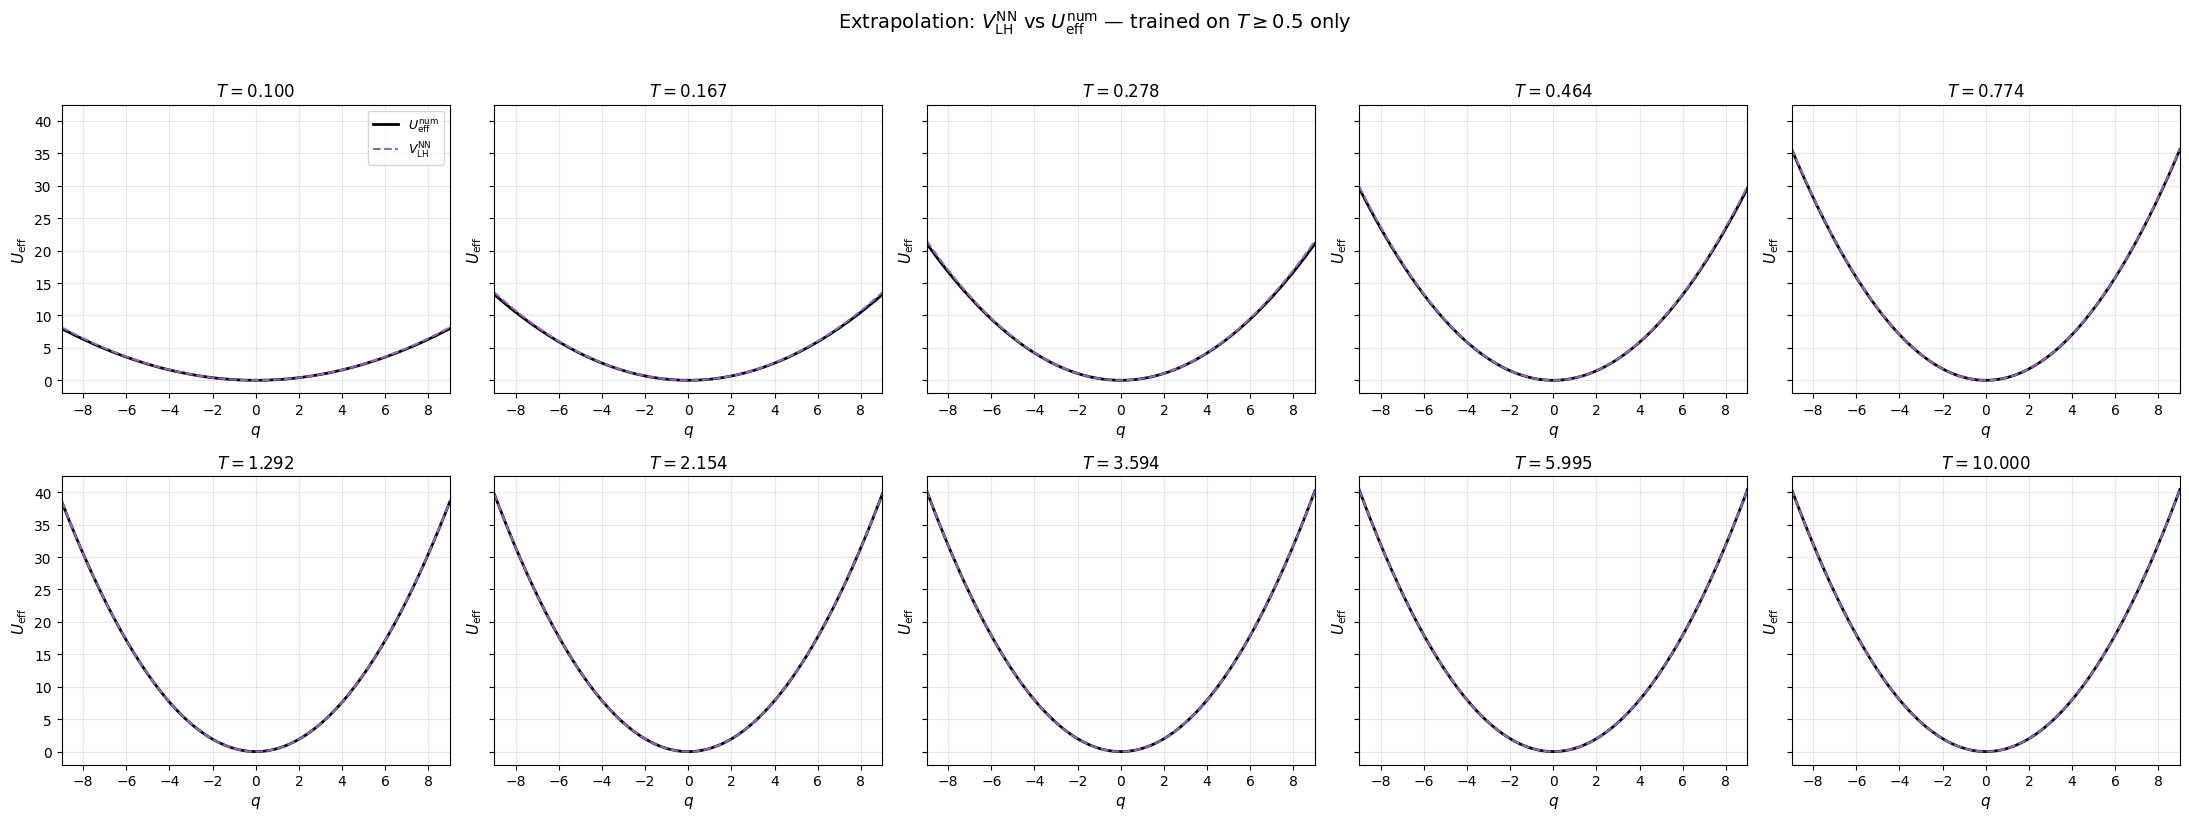

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(22, 8), sharey=True)
extrap_model.eval()

for idx, ax in enumerate(axes.flatten()):
    T = temperatures[idx]
    β = 1.0 / T
    β_t = torch.full_like(q_dense_t, β)

    with torch.no_grad():
        y_pred = extrap_model(q_dense_t, β_t).numpy().flatten()

    ax.plot(q_grid, U_eff_data[idx], 'k-', lw=2, label=r'$U_{\mathrm{eff}}^{\mathrm{num}}$')
    ax.plot(q_dense.flatten(), y_pred, '--', color='tab:purple', lw=1.5, label=r'$V_{\mathrm{LH}}^{\mathrm{NN}}$')
    ax.set_xlabel(r'$q$', fontsize=11)
    ax.set_ylabel(r'$U_{\mathrm{eff}}$', fontsize=11)
    ax.set_title(f'$T = {T:.3f}$', fontsize=12)
    ax.set_xlim(-9, 9)
    ax.grid(True, alpha=0.3)
    if idx == 0: ax.legend(fontsize=9)

fig.suptitle(r'Extrapolation: $V_{\mathrm{LH}}^{\mathrm{NN}}$ vs $U_{\mathrm{eff}}^{\mathrm{num}}$ — trained on $T \geq 0.5$ only',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('pi_extrapolation_predictions.pdf', bbox_inches='tight', dpi=300)
plt.show()
files.download('pi_extrapolation_predictions.pdf')

### $\omega_a(q)$ Stability: All-$T$ vs High-$T$-Only Training

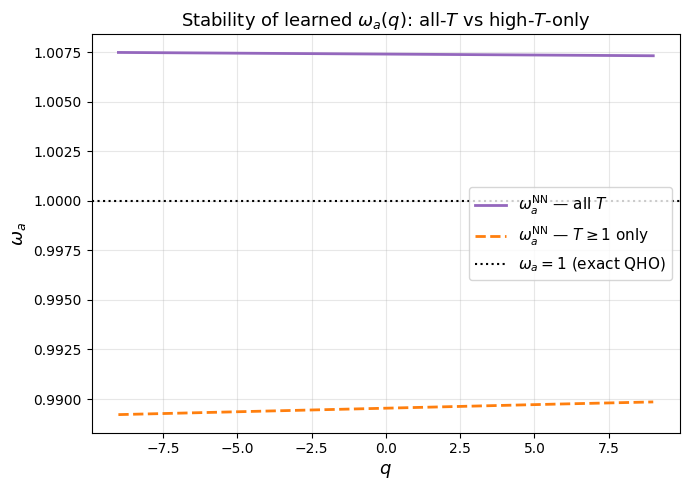

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
extrap_model.eval()
best_model.eval()

with torch.no_grad():
    omega_full   = best_model.get_omega(q_dense_t).numpy().flatten()
    omega_extrap = extrap_model.get_omega(q_dense_t).numpy().flatten()

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(q_dense.flatten(), omega_full,   '-',  color='tab:purple', lw=2,
        label=r'$\omega_a^{\mathrm{NN}}$ — all $T$')
ax.plot(q_dense.flatten(), omega_extrap, '--', color='tab:orange', lw=2,
        label=r'$\omega_a^{\mathrm{NN}}$ — $T \geq 1$ only')
ax.axhline(1.0, color='k', ls=':', lw=1.5, label=r'$\omega_a = 1$ (exact QHO)')
ax.set_xlabel(r'$q$', fontsize=13)
ax.set_ylabel(r'$\omega_a$', fontsize=13)
ax.set_title(r'Stability of learned $\omega_a(q)$: all-$T$ vs high-$T$-only', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('pi_omega_extrap.pdf', bbox_inches='tight', dpi=300)
plt.show()
files.download('pi_omega_extrap.pdf')

### Extrapolation Error

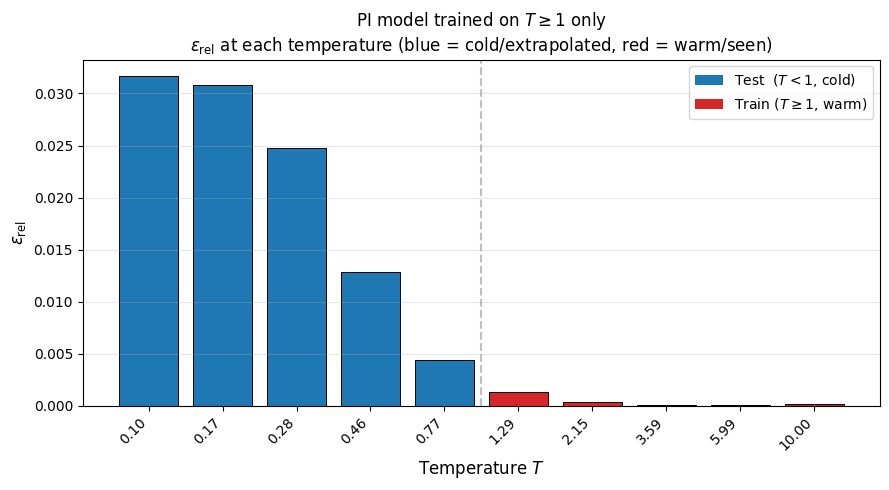

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
colors_bar = ['tab:blue' if T < 1.0 else 'tab:red' for T in temperatures]

# cutoff sits between index 4 (T≈0.77) and index 5 (T≈1.29)
cut_x = 4.5

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(range(n_temperatures), pi_rel_ex, color=colors_bar, edgecolor='k', linewidth=0.7)
ax.axvline(x=cut_x, color='gray', ls='--', lw=1.5, alpha=0.5)
ax.set_xticks(range(n_temperatures))
ax.set_xticklabels([f'{T:.2f}' for T in temperatures], rotation=45, ha='right')
ax.set_xlabel('Temperature $T$', fontsize=12)
ax.set_ylabel(r'$\varepsilon_{\mathrm{rel}}$', fontsize=12)
ax.set_title(
    r'PI model trained on $T \geq 1$ only' '\n'
    r'$\varepsilon_{\mathrm{rel}}$ at each temperature (blue = cold/extrapolated, red = warm/seen)',
    fontsize=12)
ax.yaxis.set_major_formatter(ScalarFormatter())
ax.ticklabel_format(style='plain', axis='y')
ax.grid(True, alpha=0.3, axis='y')
legend_handles = [
    Patch(facecolor='tab:blue', label=r'Test  ($T < 1$, cold)'),
    Patch(facecolor='tab:red',  label=r'Train ($T \geq 1$, warm)'),
]
ax.legend(handles=legend_handles, fontsize=10)
plt.tight_layout()
plt.savefig('pi_extrap_error_per_T.pdf', bbox_inches='tight', dpi=300)
plt.show()
files.download('pi_extrap_error_per_T.pdf')


## Extrapolation Sweep

The training cutoff $T_{\mathrm{cut}}$ is swept across 9 values ($T_{\mathrm{cut}} \in [0.17, 10]$, skipping $T_{\mathrm{cut}} = 0.1$). Each panel trains on $T \geq T_{\mathrm{cut}}$ and evaluates at all temperatures — blue bars are extrapolated, red bars are seen during training.

In [ ]:
# sweep T cutoff for extrapolation
T_cuts = temperatures.copy()  # 10 log-spaced values
n_cuts = len(T_cuts)

sweep_rel = np.zeros((n_cuts, n_temperatures))

for c_idx, T_cut in enumerate(T_cuts):
    train_idx = np.where(temperatures >= T_cut)[0]
    if len(train_idx) < 1:
        sweep_rel[c_idx] = np.nan
        print(f"T_cut = {T_cut:.4f}: only {len(train_idx)} temperature(s), skipped")
        continue

    U_hi = U_eff_data[train_idx]

    q_sw = np.tile(q_grid.reshape(-1, 1), (len(train_idx), 1))
    β_sw = np.repeat(1.0 / temperatures[train_idx], n_pos).reshape(-1, 1)
    y_sw = U_hi.reshape(-1, 1)

    rng_sw = np.random.default_rng(seed=seed)
    shuf_sw = rng_sw.permutation(len(q_sw))
    nv = max(1, len(q_sw) // 10)

    model_sw = PhysicsInformedModel(V_torch=V_torch, hidden_dims=hidden_dims)
    model_sw, _, _ = train_physics_informed(
        model_sw,
        torch.tensor(q_sw[shuf_sw[nv:]], dtype=torch.float32),
        torch.tensor(β_sw[shuf_sw[nv:]], dtype=torch.float32),
        torch.tensor(y_sw[shuf_sw[nv:]], dtype=torch.float32),
        torch.tensor(q_sw[shuf_sw[:nv]], dtype=torch.float32),
        torch.tensor(β_sw[shuf_sw[:nv]], dtype=torch.float32),
        torch.tensor(y_sw[shuf_sw[:nv]], dtype=torch.float32),
        epochs=epochs, lr=lr)

    model_sw.eval()
    q_col_t = torch.tensor(q_grid.reshape(-1, 1), dtype=torch.float32)
    with torch.no_grad():
        for i, T in enumerate(temperatures):
            pred = model_sw(q_col_t, torch.full_like(q_col_t, 1.0 / T)).numpy().flatten()
            rmse = np.sqrt(np.mean((pred - U_eff_data[i])**2))
            sweep_rel[c_idx, i] = rmse / sigma_U[i]

    print(f"T_cut = {T_cut:.4f}: trained on {len(train_idx)} temperatures")

T_cut = 0.1000: trained on 10 temperatures
T_cut = 0.1668: trained on 9 temperatures
T_cut = 0.2783: trained on 8 temperatures
T_cut = 0.4642: trained on 7 temperatures
T_cut = 0.7743: trained on 6 temperatures
T_cut = 1.2915: trained on 5 temperatures
T_cut = 2.1544: trained on 4 temperatures
T_cut = 3.5938: trained on 3 temperatures
T_cut = 5.9948: trained on 2 temperatures
T_cut = 10.0000: trained on 1 temperatures


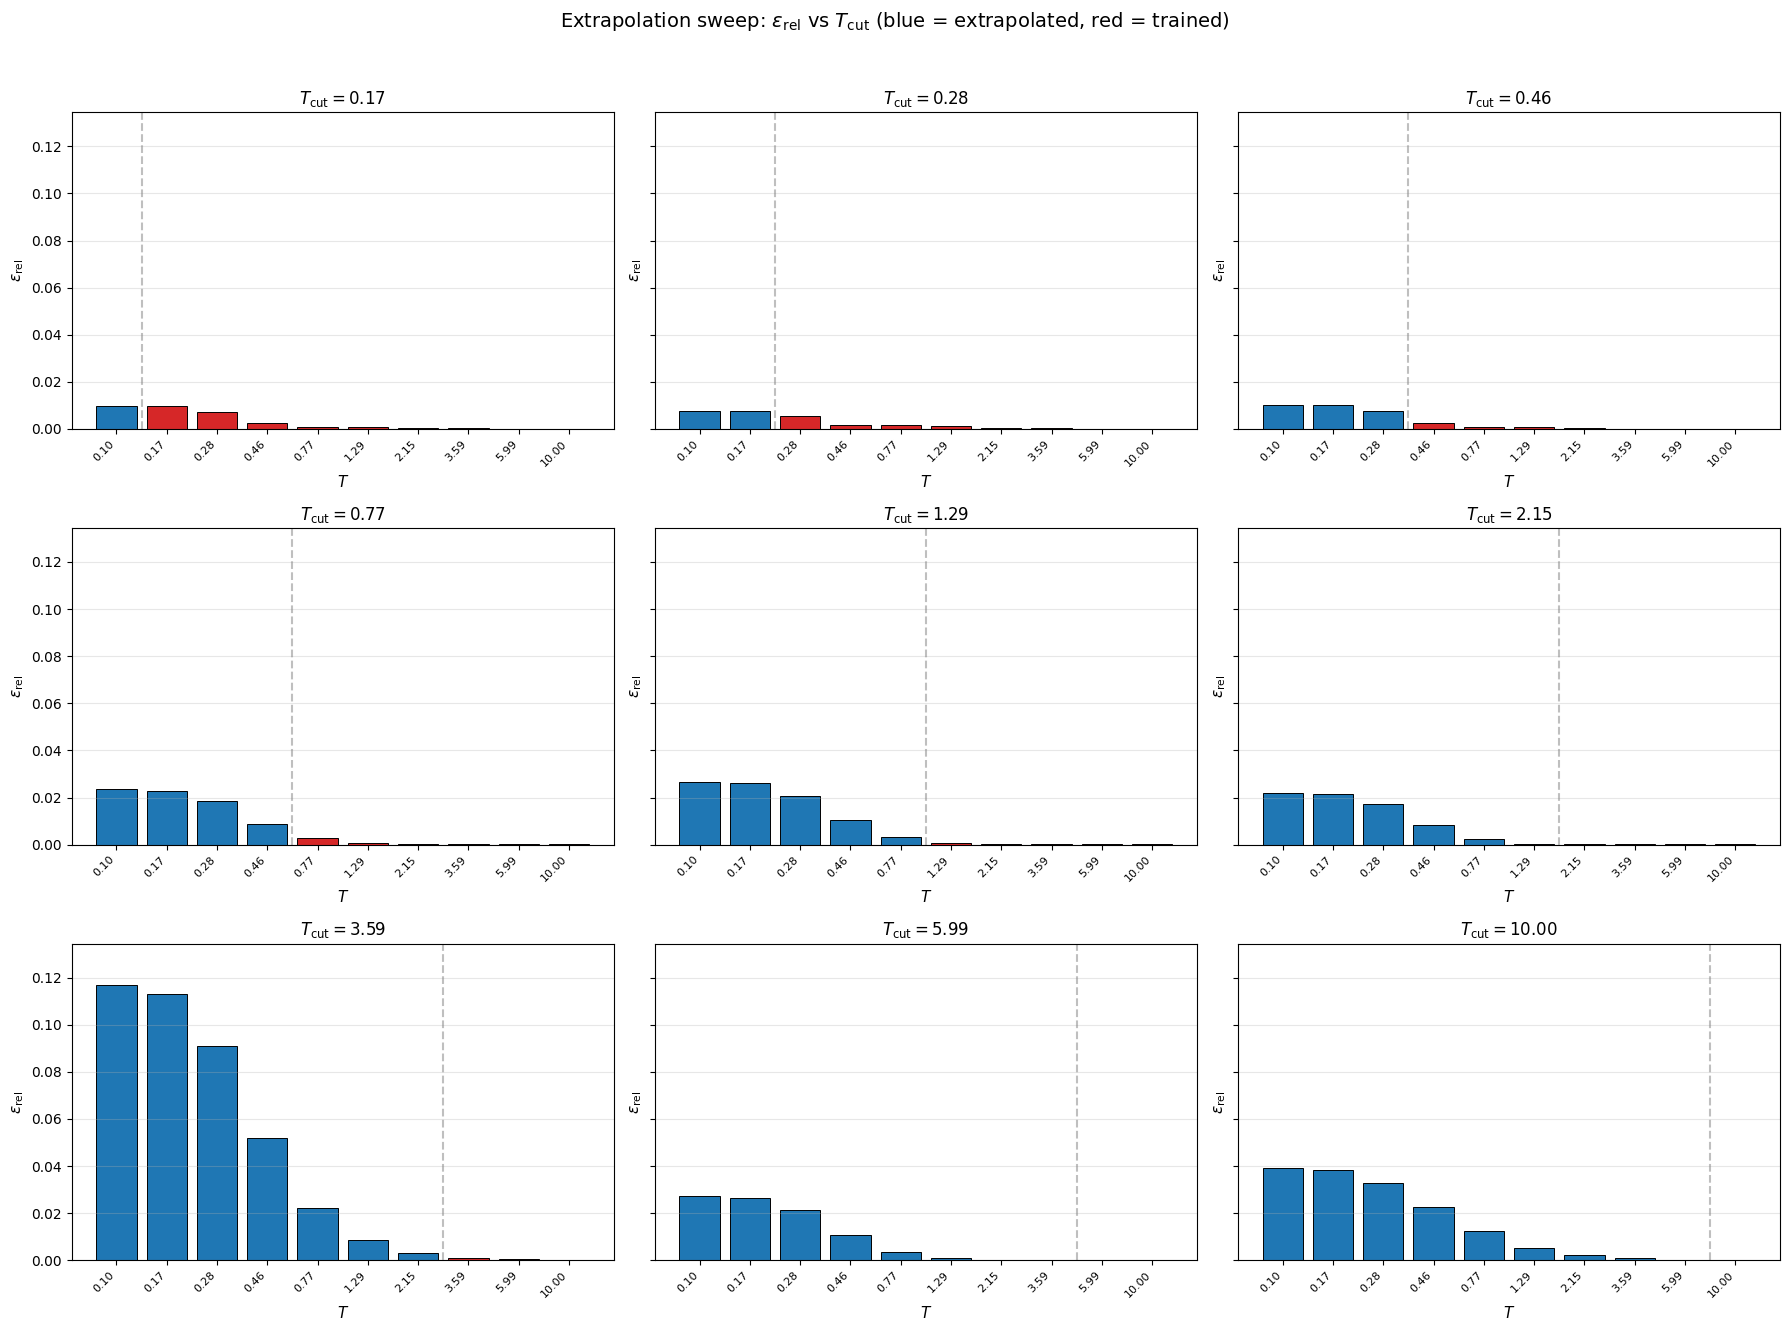

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# plot 9 panels: skip T_cut[0] (=0.10) only
plot_indices = list(range(1, n_cuts))  # indices 1..9
fig, axes = plt.subplots(3, 3, figsize=(18, 13), sharey=True)

y_max = np.nanmax(sweep_rel[plot_indices]) * 1.15

for ax, c_idx in zip(axes.flatten(), plot_indices):
    T_cut = T_cuts[c_idx]
    if np.all(np.isnan(sweep_rel[c_idx])):
        ax.set_title(f'$T_{{\\mathrm{{cut}}}} = {T_cut:.2f}$ (skipped)', fontsize=12)
        ax.axis('off')
        continue

    colors = ['tab:blue' if T < T_cut else 'tab:red' for T in temperatures]
    ax.bar(range(n_temperatures), sweep_rel[c_idx], color=colors, edgecolor='k', linewidth=0.7)

    # vertical line between last cold bar and first warm bar
    first_warm = next(i for i, T in enumerate(temperatures) if T >= T_cut)
    ax.axvline(x=first_warm - 0.5, color='gray', ls='--', lw=1.5, alpha=0.5)

    ax.set_xticks(range(n_temperatures))
    ax.set_xticklabels([f'{T:.2f}' for T in temperatures], rotation=45, ha='right', fontsize=8)
    ax.set_xlabel(r'$T$', fontsize=11)
    ax.set_ylabel(r'$\varepsilon_{\mathrm{rel}}$', fontsize=11)
    ax.set_title(f'$T_{{\\mathrm{{cut}}}} = {T_cut:.2f}$', fontsize=12)
    ax.set_ylim(0, y_max)
    ax.grid(True, alpha=0.3, axis='y')

fig.suptitle(r'Extrapolation sweep: $\varepsilon_{\mathrm{rel}}$ vs $T_{\mathrm{cut}}$ (blue = extrapolated, red = trained)',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('pi_extrap_sweep.pdf', bbox_inches='tight', dpi=300)
plt.show()
files.download('pi_extrap_sweep.pdf')
